In [1]:
import time
import pandas as pd
import numpy as np
import requests
import matplotlib as mp

API

Getting spot data

In [8]:
#spot data

url_spot = "https://api.binance.com/api/v3/klines"

end_time = int(time.time()*1000)

start_time = end_time - (3*365*24*60*60*1000)

params = {
    "symbol" : "BTCUSDT",
    "interval" : "1d",
    "startTime" : start_time,
    "endTime" : end_time,
    "limit" : 1000
}

response = requests.get(url_spot, params=params)

data = response.json()

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
1000
[1683331200000, '29505.60000000', '29820.00000000', '28300.00000000', '28848.20000000', '49249.28459000', 1683417599999, '1429517892.78050220', 1221021, '23315.95073000', '676717267.01172240', '0']


In [12]:
df = pd.DataFrame(data)

df = df.iloc[:,:6]
df.columns = ["timestamp", "open", "high", "low", "close", "volume"]

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(float)

df.head()

,timestamp,open,high,low,close,volume
0,2023-05-06,29505.60,29820.00,28300.00,28848.20,49249.28459000
1,2023-05-07,28848.19,29138.29,28395.23,28430.10,30003.41028000
2,2023-05-08,28430.09,28631.01,27262.00,27668.79,68244.36179000
3,2023-05-09,27668.80,27818.00,27353.00,27628.27,40113.31069000
4,2023-05-10,27628.28,28331.42,26777.00,27598.75,71155.11355000


Getting Futures Data

In [13]:
url_fut = "https://fapi.binance.com/fapi/v1/klines"

response_fut = requests.get(url_fut, params=params)

data_fut = response_fut.json()

print(type(data_fut))
print(data_fut[0])

<class 'list'>
[1683331200000, '29491.50', '29840.00', '28333.00', '28837.80', '475628.901', 1683417599999, '13798897391.83881', 4534010, '230364.328', '6685476928.26591', '0']


In [17]:
df_fut = pd.DataFrame(data_fut) #puts the list into a dataframe

df_fut = df_fut.iloc[:,:6] #selects only the first 6 columns
df_fut.columns = ["timestamp", "open", "high", "low", "close", "volume"] #naming the columns

df_fut["timestamp"] = pd.to_datetime(df_fut["timestamp"], unit="ms") #changes the time from ms to date and ms 

for col in ["open", "high", "low", "close"]:
    df_fut[col] = df_fut[col].astype(float) #changes the numbers from string into float

df_fut.head()

,timestamp,open,high,low,close,volume
0,2023-05-06,29491.5,29840.0,28333.0,28837.8,475628.901
1,2023-05-07,28837.9,29137.0,28370.0,28419.4,308410.643
2,2023-05-08,28419.5,28624.6,27250.0,27659.8,658188.777
3,2023-05-09,27659.8,27815.6,27316.8,27610.2,367664.686
4,2023-05-10,27610.2,28297.0,26666.6,27582.9,722502.676


Aligning prices and timestamp of both spot and perp

In [ ]:

df = df.drop("high", axis=1) # axis 0=row, 1=column
df = df.drop("low", axis=1) #deleting columns individually

df.head()

,timestamp,close,volume
0,2023-05-06,28848.20,49249.28459000
1,2023-05-07,28430.10,30003.41028000
2,2023-05-08,27668.79,68244.36179000
3,2023-05-09,27628.27,40113.31069000
4,2023-05-10,27598.75,71155.11355000


In [ ]:
df_fut = df_fut.drop(columns=["open", "high", "low"], axis=1) #deleting multimple columns in one line

df_fut.head()

,timestamp,close,volume
0,2023-05-06,28837.8,475628.901
1,2023-05-07,28419.4,308410.643
2,2023-05-08,27659.8,658188.777
3,2023-05-09,27610.2,367664.686
4,2023-05-10,27582.9,722502.676


In [29]:
#checking if the timestamps are identical
is_identical = df["timestamp"].equals(df_fut["timestamp"])

print(f"Are the timestamps identical? {is_identical}")

Are the timestamps identical? True


In [ ]:
#Renaming the columns
df.columns = ["timestamp", "spot_price", "volume"]
df_fut.columns = ["timestamp", "fut_price", "volume"]


,timestamp,spot_price,volume
0,2023-05-06,28848.20,49249.28459000
1,2023-05-07,28430.10,30003.41028000
2,2023-05-08,27668.79,68244.36179000
3,2023-05-09,27628.27,40113.31069000
4,2023-05-10,27598.75,71155.11355000


In [ ]:
#aligning all columns from future price and spot price to one dataframe
#use of concatenate to do this

df1 = pd.concat([df[["timestamp", "spot_price"]],df_fut[["fut_price"]]], axis=1).copy()

df1.head()

,timestamp,spot_price,fut_price
0,2023-05-06,28848.20,28837.8
1,2023-05-07,28430.10,28419.4
2,2023-05-08,27668.79,27659.8
3,2023-05-09,27628.27,27610.2
4,2023-05-10,27598.75,27582.9


In [50]:
type(df1["spot_price"])

pandas.core.series.Series

In [36]:
df1["timestamp"].duplicated().sum()

df1["timestamp"].is_monotonic_increasing

True

The code works because there is nothing missing, but if there is a timestamp duplication or a price missing for a timestamp, it falls apart. 

This is something to work on to improve this code

Plotting the prices

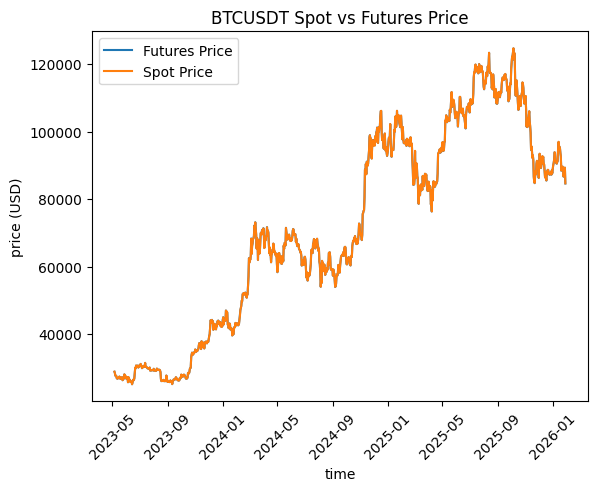

In [57]:
import matplotlib.pyplot as plt


x = df1["timestamp"]
#plt.xticks(rotation=45)

y1 = df1["fut_price"]

y2 = df1["spot_price"]


fig, ax = plt.subplots()

ax.plot(x, y1, label="Futures Price")
ax.plot(x, y2, label="Spot Price")


ax.set_xlabel("time")

ax.set_ylabel("price (USD)")

ax.set_title("BTCUSDT Spot vs Futures Price")

ax.legend()
plt.xticks(rotation=45)

plt.show()

In [60]:
spread = df1["fut_price"] - df1["spot_price"]

spread_pct = (spread)/df1["spot_price"]

rolling_mean = spread_pct.rolling(window=20).mean()

rolling_std = spread_pct.rolling(window=20).std()

z_score = (spread_pct-rolling_mean)/rolling_std

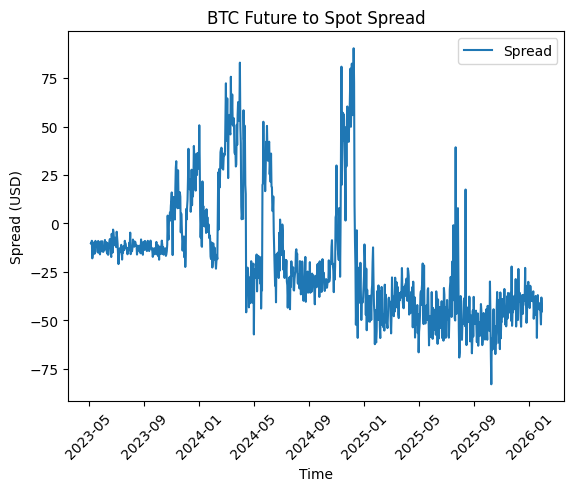

In [ ]:


y3 = spread

y4 = spread_pct

fig, ax = plt.subplots()
ax.plot(x, y3, label="Spread")
#ax.plot(x, y4, label="Spread Percentage")

ax.set_xlabel("Time")
ax.set_ylabel("Spread (USD)")
ax.set_title("BTC Future to Spot Spread")

ax.legend()
plt.xticks(rotation=45)

plt.show()

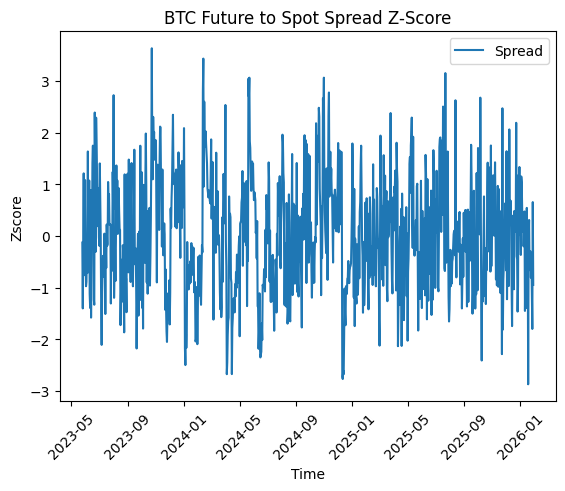

In [65]:


y5 = z_score


fig, ax = plt.subplots()
ax.plot(x, y5, label="Spread")


ax.set_xlabel("Time")
ax.set_ylabel("Zscore")
ax.set_title("BTC Future to Spot Spread Z-Score")

ax.legend()
plt.xticks(rotation=45)

plt.show()

Signal Analysis

In [ ]:
short_signal = z_score > 2
long_signal = z_score < -2

#print(z_score)
df_z = pd.DataFrame(z_score)
df_z.columns = ["zscore"]


stats_df = pd.concat([df1["timestamp"], df_z["zscore"]], axis=1).copy()



KeyError: 12